# Notebook 10 — Final combined analysis

This CPU-only notebook combines the original 2,250-trial experiment with the 750-trial image-priority intervention. It verifies parent–child integrity, estimates paired intervention effects, tests whether recovery differs by language, applies multiplicity corrections, checks dataset and response-position sensitivity, and exports the manuscript table and final figure.

The primary intervention estimand is the paired change in accuracy from `conflicting` to `conflicting_image_priority` for the same model, case, language, image, options, and conflicting note.

## 1. Mount Drive and configure inputs

In [1]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
except ImportError:
    print('Running outside Colab; using the existing /content/drive path.')

from pathlib import Path
import hashlib, json, platform, sys

ROOT=Path('/content/drive/MyDrive/Research/6. MedicalVLM_LanguageConflict/JMIR_Evidence_Selection')
MAIN_DIR=ROOT/'results'/'main_evaluation'
INT_DIR=ROOT/'results'/'image_priority_intervention'
OUTPUT=ROOT/'results'/'final_combined_analysis'
OUTPUT.mkdir(parents=True,exist_ok=True)

MAIN=MAIN_DIR/'main_all_trials.csv'
INTERVENTION=INT_DIR/'intervention_all_trials.csv'
MAIN_MANIFEST=MAIN_DIR/'main_run_manifest.json'
INT_MANIFEST=INT_DIR/'intervention_run_manifest.json'
for p in [MAIN,INTERVENTION,MAIN_MANIFEST,INT_MANIFEST]:
    assert p.is_file(),f'Missing required file: {p}'

def sha256_file(path,chunk=1024*1024):
    h=hashlib.sha256()
    with open(path,'rb') as f:
        for block in iter(lambda:f.read(chunk),b''):h.update(block)
    return h.hexdigest()

print('Main:',MAIN)
print('Intervention:',INTERVENTION)
print('Output:',OUTPUT)

Mounted at /content/drive
Main: /content/drive/MyDrive/Research/6. MedicalVLM_LanguageConflict/JMIR_Evidence_Selection/results/main_evaluation/main_all_trials.csv
Intervention: /content/drive/MyDrive/Research/6. MedicalVLM_LanguageConflict/JMIR_Evidence_Selection/results/image_priority_intervention/intervention_all_trials.csv
Output: /content/drive/MyDrive/Research/6. MedicalVLM_LanguageConflict/JMIR_Evidence_Selection/results/final_combined_analysis


## 2. Imports and fixed analysis settings

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import binomtest,chi2
try:
    from IPython.display import display
except ImportError:
    display=print

SEED=20260921
BOOTSTRAP_REPLICATES=50_000
PERMUTATION_REPLICATES=50_000
LANGUAGES=['en','id','ms']
LANGUAGE_LABELS={'en':'English','id':'Indonesian','ms':'Malay'}
MODELS=['qwen2.5vl:3b','gemma3:4b']
MODEL_LABELS={'qwen2.5vl:3b':'Qwen2.5-VL 3B','gemma3:4b':'Gemma 3 4B'}

# Record the independent language review for the study file.
MALAY_REVIEWER_INITIALS='K.S.S.'  # fill before manuscript submission
MALAY_REVIEW_DATE='2026-09-22'
MALAY_REVIEW_STATUS='Reviewed by a fluent Malay speaker; no change required.'

plt.rcParams.update({'figure.dpi':120,'savefig.dpi':300,'font.size':10,
                     'axes.spines.top':False,'axes.spines.right':False})

## 3. Integrity validation and paired dataset

In [3]:
main_manifest=json.loads(MAIN_MANIFEST.read_text(encoding='utf-8'))
int_manifest=json.loads(INT_MANIFEST.read_text(encoding='utf-8'))
main=pd.read_csv(MAIN)
intervention=pd.read_csv(INTERVENTION)

assert sha256_file(MAIN)==int_manifest['parent_main_results_sha256']
assert main_manifest['casebook_sha256']==int_manifest['casebook_sha256']
for model in MODELS:
    assert main_manifest['models'][model]['digest']==int_manifest['models'][model]['digest']
assert len(main)==2250 and main.trial_id.nunique()==2250 and main.status.eq('ok').all()
assert len(intervention)==750 and intervention.trial_id.nunique()==750 and intervention.status.eq('ok').all()
assert intervention.condition.eq('conflicting_image_priority').all()
assert intervention.parsed_letter.notna().all()

original=main[main.condition.eq('conflicting')].copy()
assert len(original)==750
keys=['model','case_id','dataset','language']
paired=original.merge(intervention,on=keys,suffixes=('_original','_priority'),validate='one_to_one')
assert len(paired)==750
for col in ['image_sha256','correct_letter','note_letter','reference_answer','option_a','option_b']:
    assert paired[f'{col}_original'].astype(str).equals(paired[f'{col}_priority'].astype(str)),col

for col in ['is_correct_original','is_correct_priority','follows_note_original','follows_note_priority']:
    if paired[col].dtype!=bool:
        paired[col]=paired[col].astype(str).str.lower().map({'true':True,'false':False})
    assert paired[col].notna().all(),col

paired['delta_accuracy']=paired.is_correct_priority.astype(int)-paired.is_correct_original.astype(int)
paired['delta_note_follow']=paired.follows_note_priority.astype(int)-paired.follows_note_original.astype(int)
paired.to_csv(OUTPUT/'paired_analysis_frozen.csv',index=False)
print('Integrity validation passed: 750 exactly paired intervention comparisons.')
print('Intervention wording SHA256:',int_manifest['intervention_wording_sha256'])
display(pd.DataFrame(int_manifest['intervention_wording'].items(),columns=['language','instruction']))

Integrity validation passed: 750 exactly paired intervention comparisons.
Intervention wording SHA256: f852e0cb5f7f5a045c32b5ef138af0c753f7f8b3ddfe7397f557b3e191cd0a5e


,language,instruction
0,en,Use the medical image as the primary source of...
1,id,Gunakan citra medis sebagai sumber bukti utama...
2,ms,Gunakan imej perubatan sebagai sumber bukti ut...


## 4. Statistical functions

In [4]:
def holm_adjust(p_values):
    p=np.asarray(p_values,float);order=np.argsort(p);out=np.empty_like(p);running=0.0;m=len(p)
    for rank,index in enumerate(order):
        running=max(running,(m-rank)*p[index]);out[index]=min(running,1.0)
    return out

def exact_mcnemar(x,y):
    x=np.asarray(x,bool);y=np.asarray(y,bool)
    x_only=int((x&~y).sum());y_only=int((~x&y).sum());n=x_only+y_only
    p=1.0 if n==0 else binomtest(min(x_only,y_only),n,.5).pvalue
    return x_only,y_only,p

def paired_bootstrap_delta(delta,confidence=.95,reps=BOOTSTRAP_REPLICATES,seed=SEED):
    delta=np.asarray(delta,float);rng=np.random.default_rng(seed);n=len(delta);draws=np.empty(reps)
    for start in range(0,reps,2500):
        stop=min(start+2500,reps);idx=rng.integers(0,n,size=(stop-start,n));draws[start:stop]=delta[idx].mean(1)
    alpha=1-confidence;lo,hi=np.quantile(draws,[alpha/2,1-alpha/2])
    return float(delta.mean()),float(lo),float(hi)

def paired_permutation_difference(x,y,reps=PERMUTATION_REPLICATES,seed=SEED):
    d=np.asarray(x,float)-np.asarray(y,float);observed=float(d.mean());rng=np.random.default_rng(seed);extreme=0
    for start in range(0,reps,2500):
        stop=min(start+2500,reps);signs=rng.choice([-1,1],size=(stop-start,len(d)))
        values=(signs*d).mean(1);extreme+=int((np.abs(values)>=abs(observed)-1e-15).sum())
    return observed,(extreme+1)/(reps+1)

def recovery_omnibus_permutation(matrix,reps=PERMUTATION_REPLICATES,seed=SEED):
    x=np.asarray(matrix,float);means=x.mean(0);observed=float(((means-means.mean())**2).sum())
    rng=np.random.default_rng(seed);extreme=0;n,k=x.shape
    for start in range(0,reps,1000):
        size=min(1000,reps-start)
        perm=rng.random((size,n,k)).argsort(axis=2)
        xp=np.take_along_axis(np.broadcast_to(x,(size,n,k)),perm,axis=2)
        m=xp.mean(1);stat=((m-m.mean(1,keepdims=True))**2).sum(1)
        extreme+=int((stat>=observed-1e-15).sum())
    return observed,(extreme+1)/(reps+1)

def wilson_ci(successes,n,confidence=.95):
    from scipy.stats import norm
    z=norm.ppf(1-(1-confidence)/2);p=successes/n;den=1+z*z/n
    center=(p+z*z/(2*n))/den;half=z*np.sqrt(p*(1-p)/n+z*z/(4*n*n))/den
    return center-half,center+half

## 5. Primary paired intervention effects

In [5]:
rows=[]
for index,((model,language),g) in enumerate(paired.groupby(['model','language'],sort=False)):
    orig=g.is_correct_original.to_numpy(bool);priority=g.is_correct_priority.to_numpy(bool)
    original_only,priority_only,p=exact_mcnemar(orig,priority)
    effect,lo,hi=paired_bootstrap_delta(g.delta_accuracy,seed=SEED+index)
    rows.append({'model':model,'language':language,'n':len(g),
        'accuracy_original_conflict':orig.mean(),'accuracy_image_priority':priority.mean(),
        'accuracy_recovery':effect,'recovery_ci95_low':lo,'recovery_ci95_high':hi,
        'note_follow_original':g.follows_note_original.mean(),
        'note_follow_priority':g.follows_note_priority.mean(),
        'note_follow_reduction':-g.delta_note_follow.mean(),
        'original_correct_only':original_only,'priority_correct_only':priority_only,
        'mcnemar_p_raw':p})
primary=pd.DataFrame(rows)
primary['mcnemar_p_holm_6']=holm_adjust(primary.mcnemar_p_raw)
primary['significant_holm_05']=primary.mcnemar_p_holm_6.lt(.05)
primary.to_csv(OUTPUT/'table_primary_intervention_effects.csv',index=False)
display(primary)

,model,language,n,accuracy_original_conflict,accuracy_image_priority,accuracy_recovery,recovery_ci95_low,recovery_ci95_high,note_follow_original,note_follow_priority,note_follow_reduction,original_correct_only,priority_correct_only,mcnemar_p_raw,mcnemar_p_holm_6,significant_holm_05
0,qwen2.5vl:3b,id,125,0.048,0.080,0.032,-0.008,0.080,0.952,0.920,0.032,2,6,2.890625e-01,8.671875e-01,False
1,qwen2.5vl:3b,en,125,0.056,0.248,0.192,0.128,0.264,0.944,0.752,0.192,0,24,1.192093e-07,5.960464e-07,True
2,qwen2.5vl:3b,ms,125,0.056,0.104,0.048,0.016,0.088,0.944,0.896,0.048,0,6,3.125000e-02,1.250000e-01,False
3,gemma3:4b,id,125,0.048,0.040,-0.008,-0.024,0.000,0.952,0.960,-0.008,1,0,1.000000e+00,1.000000e+00,False
4,gemma3:4b,en,125,0.040,0.368,0.328,0.248,0.408,0.960,0.632,0.328,0,41,9.094947e-13,5.456968e-12,True
5,gemma3:4b,ms,125,0.080,0.064,-0.016,-0.056,0.024,0.920,0.936,-0.016,4,2,6.875000e-01,1.000000e+00,False


## 6. Does intervention recovery differ by language?

The omnibus test permutes language labels within each case and tests differences among the three paired recovery scores. Pairwise tests compare case-level recovery scores between languages and use Holm correction within each model.

In [6]:
omnibus_rows=[];pair_rows=[]
for mi,model in enumerate(MODELS):
    wide=paired[paired.model.eq(model)].pivot(index='case_id',columns='language',values='delta_accuracy')[LANGUAGES]
    stat,p=recovery_omnibus_permutation(wide.values,seed=SEED+100+mi)
    omnibus_rows.append({'model':model,'n_cases':len(wide),'recovery_en':wide.en.mean(),
                          'recovery_id':wide.id.mean(),'recovery_ms':wide.ms.mean(),
                          'permutation_statistic':stat,'permutation_p':p})
    local=[]
    for pi,(left,right) in enumerate([('en','id'),('en','ms'),('id','ms')]):
        difference,pair_p=paired_permutation_difference(wide[left],wide[right],seed=SEED+200+mi*10+pi)
        _,lo,hi=paired_bootstrap_delta((wide[left]-wide[right]).values,seed=SEED+300+mi*10+pi)
        local.append({'model':model,'language_left':left,'language_right':right,'n_cases':len(wide),
                      'difference_in_recovery':difference,'ci95_low':lo,'ci95_high':hi,
                      'permutation_p_raw':pair_p})
    adjusted=holm_adjust([r['permutation_p_raw'] for r in local])
    for r,padj in zip(local,adjusted):r['permutation_p_holm_within_model']=padj;pair_rows.append(r)

recovery_omnibus=pd.DataFrame(omnibus_rows);recovery_pairs=pd.DataFrame(pair_rows)
recovery_omnibus.to_csv(OUTPUT/'table_recovery_language_omnibus.csv',index=False)
recovery_pairs.to_csv(OUTPUT/'table_recovery_language_pairs.csv',index=False)
display(recovery_omnibus);display(recovery_pairs)

,model,n_cases,recovery_en,recovery_id,recovery_ms,permutation_statistic,permutation_p
0,qwen2.5vl:3b,125,0.192,0.032,0.048,0.015531,0.00002
1,gemma3:4b,125,0.328,-0.008,-0.016,0.077099,0.00002


,model,language_left,language_right,n_cases,difference_in_recovery,ci95_low,ci95_high,permutation_p_raw,permutation_p_holm_within_model
0,qwen2.5vl:3b,en,id,125,0.160,0.088,0.232,0.000040,0.000120
1,qwen2.5vl:3b,en,ms,125,0.144,0.080,0.216,0.000180,0.000360
2,qwen2.5vl:3b,id,ms,125,-0.016,-0.064,0.024,0.724126,0.724126
3,gemma3:4b,en,id,125,0.336,0.248,0.424,0.000020,0.000060
4,gemma3:4b,en,ms,125,0.344,0.256,0.440,0.000020,0.000060
5,gemma3:4b,id,ms,125,0.008,-0.024,0.048,1.000000,1.000000


## 7. Dataset-stratified sensitivity

In [7]:
rows=[]
for index,((model,dataset,language),g) in enumerate(paired.groupby(['model','dataset','language'])):
    effect,lo,hi=paired_bootstrap_delta(g.delta_accuracy,seed=SEED+400+index)
    original_only,priority_only,p=exact_mcnemar(g.is_correct_original,g.is_correct_priority)
    rows.append({'model':model,'dataset':dataset,'language':language,'n':len(g),
                 'accuracy_original':g.is_correct_original.mean(),'accuracy_priority':g.is_correct_priority.mean(),
                 'accuracy_recovery':effect,'ci95_low':lo,'ci95_high':hi,
                 'note_follow_original':g.follows_note_original.mean(),
                 'note_follow_priority':g.follows_note_priority.mean(),
                 'mcnemar_p_raw':p})
dataset_table=pd.DataFrame(rows)
dataset_table.to_csv(OUTPUT/'table_dataset_sensitivity.csv',index=False)
display(dataset_table)

,model,dataset,language,n,accuracy_original,accuracy_priority,accuracy_recovery,ci95_low,ci95_high,note_follow_original,note_follow_priority,mcnemar_p_raw
0,gemma3:4b,slake,en,25,0.08,0.64,0.56,0.36,0.76,0.92,0.36,1.220703e-04
1,gemma3:4b,slake,id,25,0.08,0.08,0.00,0.00,0.00,0.92,0.92,1.000000e+00
2,gemma3:4b,slake,ms,25,0.12,0.12,0.00,-0.12,0.12,0.88,0.88,1.000000e+00
3,gemma3:4b,vqa_rad,en,100,0.03,0.30,0.27,0.19,0.36,0.97,0.70,1.490116e-08
4,gemma3:4b,vqa_rad,id,100,0.04,0.03,-0.01,-0.03,0.00,0.96,0.97,1.000000e+00
5,gemma3:4b,vqa_rad,ms,100,0.07,0.05,-0.02,-0.06,0.02,0.93,0.95,6.250000e-01
6,qwen2.5vl:3b,slake,en,25,0.12,0.60,0.48,0.28,0.68,0.88,0.40,4.882812e-04
7,qwen2.5vl:3b,slake,id,25,0.12,0.20,0.08,-0.08,0.24,0.88,0.80,6.250000e-01
8,qwen2.5vl:3b,slake,ms,25,0.08,0.16,0.08,0.00,0.20,0.92,0.84,5.000000e-01
9,qwen2.5vl:3b,vqa_rad,en,100,0.04,0.16,0.12,0.06,0.19,0.96,0.84,4.882812e-04


## 8. Answer-position and reference-answer sensitivity

In [8]:
position=(paired.groupby(['model','language','correct_letter_priority'])
          .agg(n=('case_id','size'),accuracy_original=('is_correct_original','mean'),
               accuracy_priority=('is_correct_priority','mean'),recovery=('delta_accuracy','mean'))
          .reset_index())
reference=(paired.groupby(['model','language','reference_answer_priority'])
           .agg(n=('case_id','size'),accuracy_original=('is_correct_original','mean'),
                accuracy_priority=('is_correct_priority','mean'),recovery=('delta_accuracy','mean'))
           .reset_index())
position.to_csv(OUTPUT/'table_position_sensitivity.csv',index=False)
reference.to_csv(OUTPUT/'table_reference_answer_sensitivity.csv',index=False)
display(position);display(reference)

,model,language,correct_letter_priority,n,accuracy_original,accuracy_priority,recovery
0,gemma3:4b,en,A,81,0.012346,0.271605,0.259259
1,gemma3:4b,en,B,44,0.090909,0.545455,0.454545
2,gemma3:4b,id,A,57,0.000000,0.000000,0.000000
3,gemma3:4b,id,B,68,0.088235,0.073529,-0.014706
4,gemma3:4b,ms,A,57,0.035088,0.017544,-0.017544
5,gemma3:4b,ms,B,68,0.117647,0.102941,-0.014706
6,qwen2.5vl:3b,en,A,81,0.037037,0.246914,0.209877
7,qwen2.5vl:3b,en,B,44,0.090909,0.250000,0.159091
8,qwen2.5vl:3b,id,A,57,0.035088,0.052632,0.017544
9,qwen2.5vl:3b,id,B,68,0.058824,0.102941,0.044118


,model,language,reference_answer_priority,n,accuracy_original,accuracy_priority,recovery
0,gemma3:4b,en,no,63,0.031746,0.158730,0.126984
1,gemma3:4b,en,yes,62,0.048387,0.580645,0.532258
2,gemma3:4b,id,no,63,0.031746,0.031746,0.000000
3,gemma3:4b,id,yes,62,0.064516,0.048387,-0.016129
4,gemma3:4b,ms,no,63,0.015873,0.015873,0.000000
5,gemma3:4b,ms,yes,62,0.145161,0.112903,-0.032258
6,qwen2.5vl:3b,en,no,63,0.063492,0.253968,0.190476
7,qwen2.5vl:3b,en,yes,62,0.048387,0.241935,0.193548
8,qwen2.5vl:3b,id,no,63,0.047619,0.111111,0.063492
9,qwen2.5vl:3b,id,yes,62,0.048387,0.048387,0.000000


## 9. Manuscript-ready compact table

In [9]:
image_only=(main[main.condition.eq('image_only')]
            .groupby(['model','language']).is_correct.mean().rename('image_only_accuracy'))
manuscript=(primary.set_index(['model','language']).join(image_only).reset_index())
manuscript=manuscript[['model','language','n','image_only_accuracy','accuracy_original_conflict',
                       'accuracy_image_priority','accuracy_recovery','recovery_ci95_low','recovery_ci95_high',
                       'note_follow_original','note_follow_priority','mcnemar_p_holm_6']]
manuscript.to_csv(OUTPUT/'table_manuscript.csv',index=False)

formatted=manuscript.copy()
for c in ['image_only_accuracy','accuracy_original_conflict','accuracy_image_priority',
          'accuracy_recovery','recovery_ci95_low','recovery_ci95_high',
          'note_follow_original','note_follow_priority']:
    formatted[c]=(100*formatted[c]).round(1)
formatted['recovery_95ci']=formatted.apply(
    lambda r:f"{r.accuracy_recovery:.1f} ({r.recovery_ci95_low:.1f} to {r.recovery_ci95_high:.1f})",axis=1)
formatted['note_following_before_to_after']=formatted.apply(
    lambda r:f"{r.note_follow_original:.1f} to {r.note_follow_priority:.1f}",axis=1)
formatted['model']=formatted.model.map(MODEL_LABELS);formatted['language']=formatted.language.map(LANGUAGE_LABELS)
formatted=formatted[['model','language','n','image_only_accuracy','accuracy_original_conflict',
                     'accuracy_image_priority','recovery_95ci','note_following_before_to_after','mcnemar_p_holm_6']]
formatted.to_csv(OUTPUT/'table_manuscript_formatted.csv',index=False)
display(formatted)

,model,language,n,image_only_accuracy,accuracy_original_conflict,accuracy_image_priority,recovery_95ci,note_following_before_to_after,mcnemar_p_holm_6
0,Qwen2.5-VL 3B,Indonesian,125,60.0,4.8,8.0,3.2 (-0.8 to 8.0),95.2 to 92.0,8.671875e-01
1,Qwen2.5-VL 3B,English,125,71.2,5.6,24.8,19.2 (12.8 to 26.4),94.4 to 75.2,5.960464e-07
2,Qwen2.5-VL 3B,Malay,125,64.8,5.6,10.4,4.8 (1.6 to 8.8),94.4 to 89.6,1.250000e-01
3,Gemma 3 4B,Indonesian,125,61.6,4.8,4.0,-0.8 (-2.4 to 0.0),95.2 to 96.0,1.000000e+00
4,Gemma 3 4B,English,125,60.0,4.0,36.8,32.8 (24.8 to 40.8),96.0 to 63.2,5.456968e-12
5,Gemma 3 4B,Malay,125,60.0,8.0,6.4,-1.6 (-5.6 to 2.4),92.0 to 93.6,1.000000e+00


## 10. Final manuscript figure

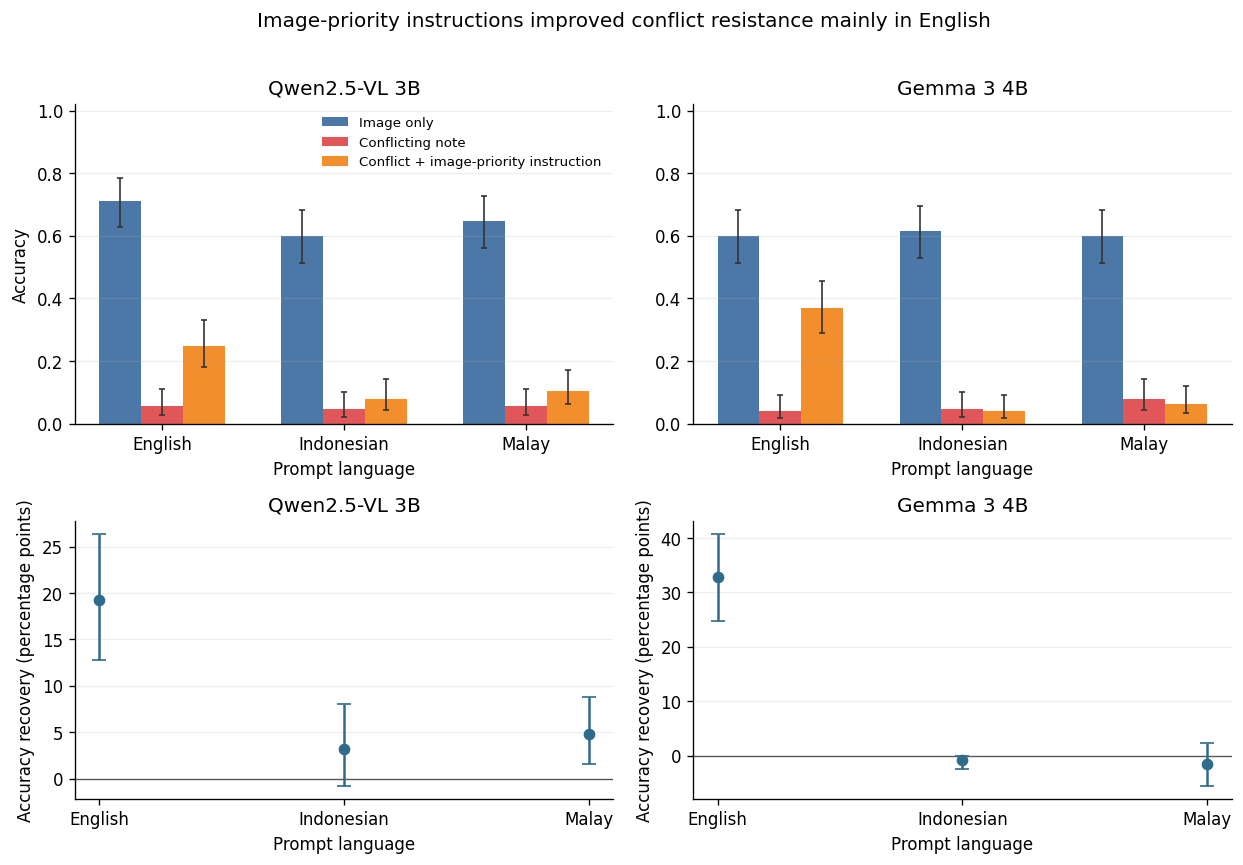

In [10]:
colors={'image_only':'#4C78A8','conflicting':'#E15759','priority':'#F28E2B'}
fig,axes=plt.subplots(2,2,figsize=(10.5,7.2),gridspec_kw={'height_ratios':[1.15,1]})
x=np.arange(3);width=.23

for ax,model in zip(axes[0],MODELS):
    for j,(key,label) in enumerate([('image_only','Image only'),('conflicting','Conflicting note'),('priority','Conflict + image-priority instruction')]):
        vals=[];loerr=[];hierr=[]
        for language in LANGUAGES:
            if key=='priority':g=intervention[(intervention.model==model)&(intervention.language==language)]
            else:g=main[(main.model==model)&(main.language==language)&(main.condition==key)]
            success=int(g.is_correct.sum());n=len(g);lo,hi=wilson_ci(success,n);rate=success/n
            vals.append(rate);loerr.append(rate-lo);hierr.append(hi-rate)
        pos=x+(j-1)*width
        ax.bar(pos,vals,width,label=label,color=colors[key])
        ax.errorbar(pos,vals,yerr=[loerr,hierr],fmt='none',ecolor='#333',elinewidth=1,capsize=2)
    ax.set_title(MODEL_LABELS[model]);ax.set_xticks(x,[LANGUAGE_LABELS[l] for l in LANGUAGES])
    ax.set_ylim(0,1.02);ax.grid(axis='y',alpha=.2);ax.set_xlabel('Prompt language')
axes[0,0].set_ylabel('Accuracy');axes[0,0].legend(frameon=False,fontsize=8,loc='upper right')

for ax,model in zip(axes[1],MODELS):
    g=primary[primary.model.eq(model)].set_index('language').loc[LANGUAGES]
    vals=100*g.accuracy_recovery.values
    low=100*(g.accuracy_recovery-g.recovery_ci95_low).values
    high=100*(g.recovery_ci95_high-g.accuracy_recovery).values
    ax.axhline(0,color='#555',linewidth=.8)
    ax.errorbar(x,vals,yerr=[low,high],fmt='o',color='#2F6B8A',capsize=4,markersize=6)
    ax.set_xticks(x,[LANGUAGE_LABELS[l] for l in LANGUAGES]);ax.set_title(MODEL_LABELS[model])
    ax.set_ylabel('Accuracy recovery (percentage points)');ax.grid(axis='y',alpha=.2);ax.set_xlabel('Prompt language')

fig.suptitle('Image-priority instructions improved conflict resistance mainly in English',fontsize=12,y=.995)
fig.tight_layout(rect=[0,0,1,.98])
fig.savefig(OUTPUT/'figure_final_intervention.png',bbox_inches='tight')
fig.savefig(OUTPUT/'figure_final_intervention.pdf',bbox_inches='tight')
plt.show()

## 11. Export manifest and interpretation summary

In [11]:
manifest={'completed_at_utc':pd.Timestamp.utcnow().isoformat(),
          'main_input_sha256':sha256_file(MAIN),'intervention_input_sha256':sha256_file(INTERVENTION),
          'main_manifest_sha256':sha256_file(MAIN_MANIFEST),'intervention_manifest_sha256':sha256_file(INT_MANIFEST),
          'analysis_seed':SEED,'bootstrap_replicates':BOOTSTRAP_REPLICATES,
          'permutation_replicates':PERMUTATION_REPLICATES,'n_paired_trials':len(paired),
          'malay_review':{'initials':MALAY_REVIEWER_INITIALS,'date':MALAY_REVIEW_DATE,'status':MALAY_REVIEW_STATUS},
          'python_version':sys.version,'platform':platform.platform()}
(OUTPUT/'final_analysis_manifest.json').write_text(json.dumps(manifest,indent=2),encoding='utf-8')

lines=['FINAL COMBINED ANALYSIS','=======================']
for _,r in primary.iterrows():
    lines.append(f"{MODEL_LABELS[r.model]}, {LANGUAGE_LABELS[r.language]}: recovery {100*r.accuracy_recovery:.1f} pp "
                 f"(95% CI {100*r.recovery_ci95_low:.1f} to {100*r.recovery_ci95_high:.1f}); "
                 f"Holm-adjusted P={r.mcnemar_p_holm_6:.4g}.")
lines.append('')
for _,r in recovery_omnibus.iterrows():
    lines.append(f"{MODEL_LABELS[r.model]} language heterogeneity permutation P={r.permutation_p:.4g}.")
lines += ['', 'Interpretation: the image-priority instruction produced clear partial recovery in English,',
          'but little or no reliable recovery in Indonesian or Malay. Even in English, residual',
          'conflicting-note following remained substantial; the intervention was not a complete safeguard.']
(OUTPUT/'final_analysis_summary.txt').write_text('\n'.join(lines),encoding='utf-8')
print('\n'.join(lines))
print('\nExported files:')
for p in sorted(OUTPUT.iterdir()):print(p.name)

FINAL COMBINED ANALYSIS
Qwen2.5-VL 3B, Indonesian: recovery 3.2 pp (95% CI -0.8 to 8.0); Holm-adjusted P=0.8672.
Qwen2.5-VL 3B, English: recovery 19.2 pp (95% CI 12.8 to 26.4); Holm-adjusted P=5.96e-07.
Qwen2.5-VL 3B, Malay: recovery 4.8 pp (95% CI 1.6 to 8.8); Holm-adjusted P=0.125.
Gemma 3 4B, Indonesian: recovery -0.8 pp (95% CI -2.4 to 0.0); Holm-adjusted P=1.
Gemma 3 4B, English: recovery 32.8 pp (95% CI 24.8 to 40.8); Holm-adjusted P=5.457e-12.
Gemma 3 4B, Malay: recovery -1.6 pp (95% CI -5.6 to 2.4); Holm-adjusted P=1.

Qwen2.5-VL 3B language heterogeneity permutation P=2e-05.
Gemma 3 4B language heterogeneity permutation P=2e-05.

Interpretation: the image-priority instruction produced clear partial recovery in English,
but little or no reliable recovery in Indonesian or Malay. Even in English, residual
conflicting-note following remained substantial; the intervention was not a complete safeguard.

Exported files:
figure_final_intervention.pdf
figure_final_intervention.png
fina

## Interpretation guardrails

- Describe the intervention as **partially effective in English**, not successful overall.
- Describe Indonesian and Malay results as showing little or no reliable recovery after multiplicity correction.
- The experiment tests two small, locally quantized general-purpose vision-language models on binary medical VQA; it does not establish behavior for all clinical systems.
- Report the independent Malay-language review accurately. Do not call it clinical validation unless the reviewer has relevant clinical expertise.
- The post hoc intervention strengthens the study but should be labeled as a prespecified follow-up conducted after inspecting the original experiment, not as part of a preregistered protocol.